# Residual Patters

In [18]:
import os
os.getcwd()

'/Users/robertwrobel'

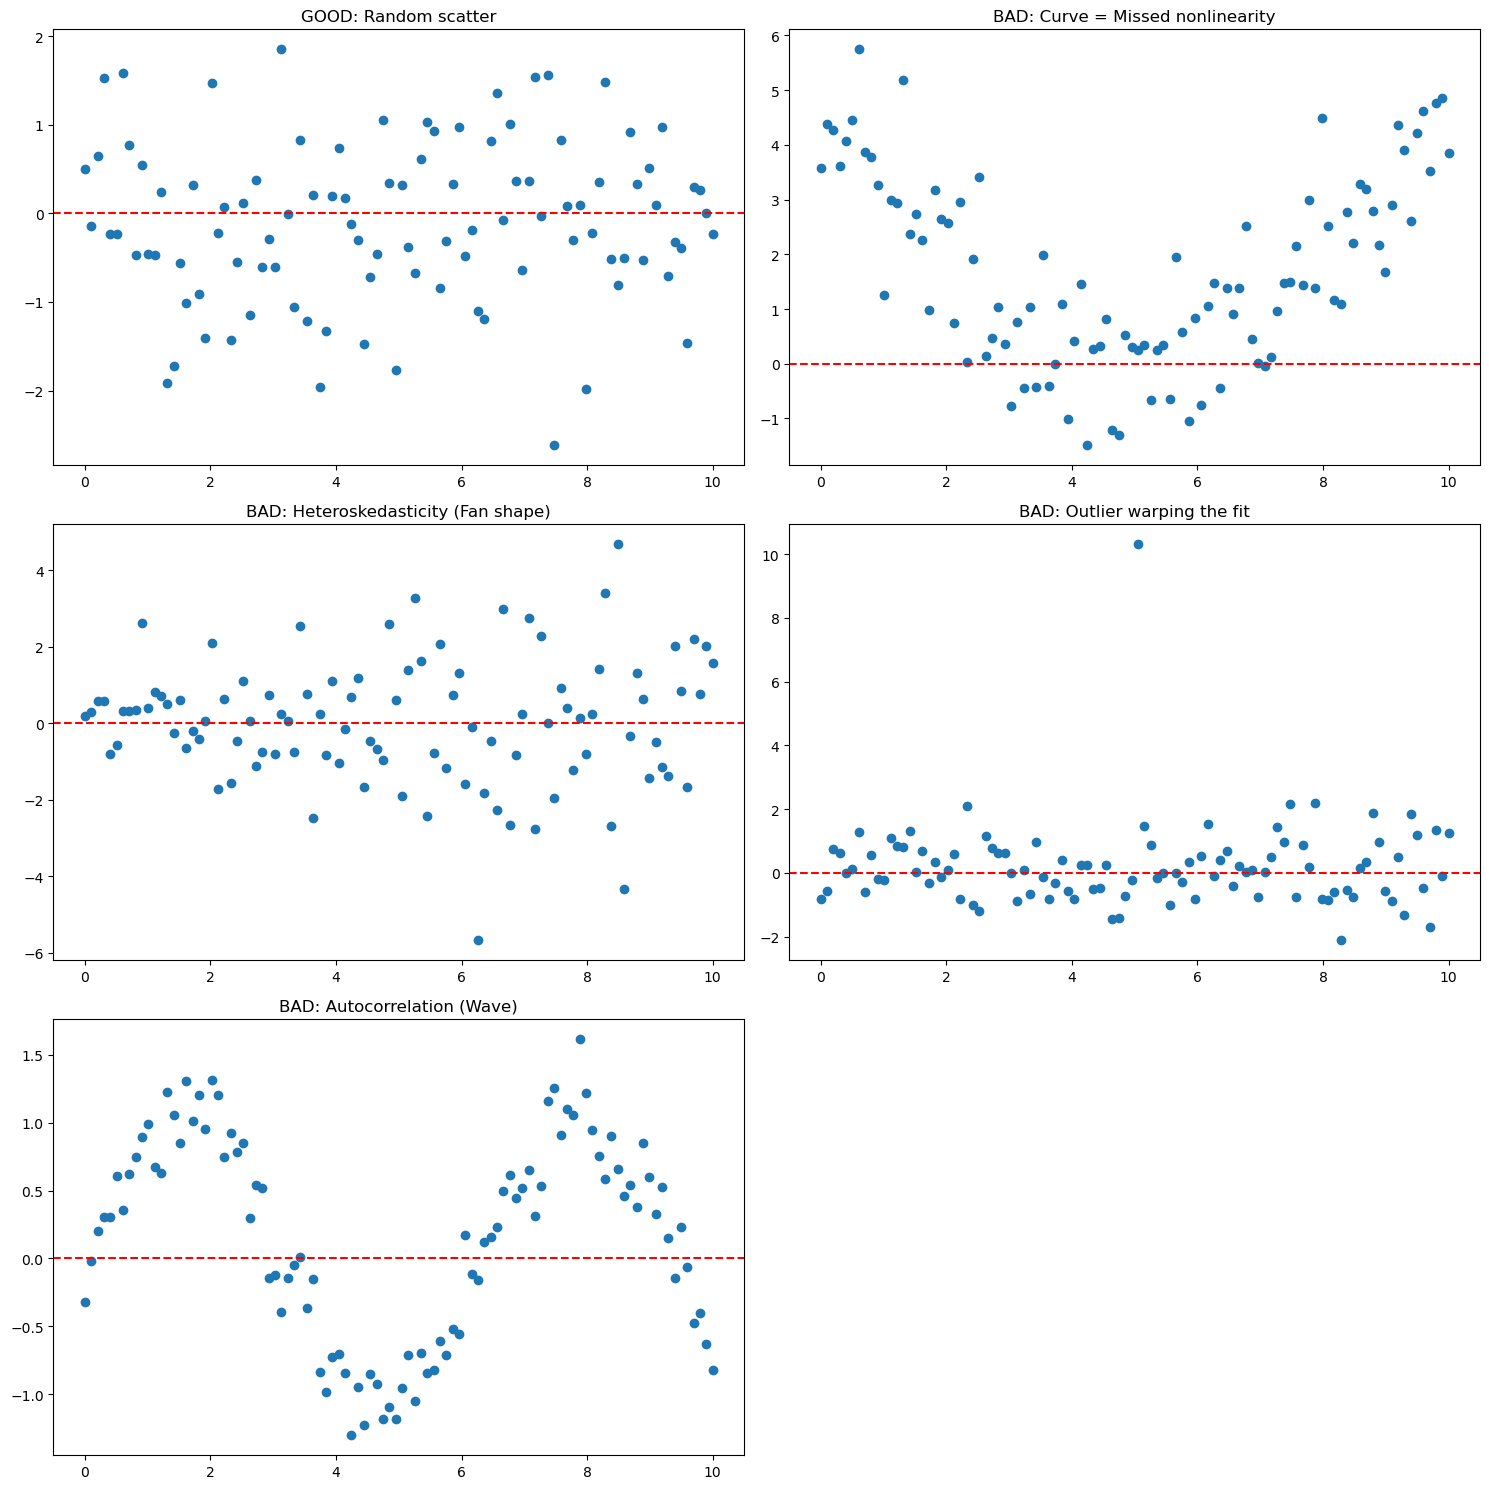

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
x = np.linspace(0, 10, n)

#Random scatter
residuals_random = np.random.normal(0, 1, n)

#Curved pattern (missed non-linearity)
residuals_curve = (x - 5)**2 / 5 + np.random.normal(0, 1, n)

#Heteroskedasticity (fanning out)
residuals_fan = np.random.normal(0, 0.2 * x + 0.5, n)

#Outlier present
residuals_outlier = np.random.normal(0, 1, n)
residuals_outlier[50] += 10  # One huge outlier

#Autocorrelation (wave pattern)
residuals_wave = np.sin(x) + np.random.normal(0, 0.2, n)

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
axs = axs.flatten()

axs[0].scatter(x, residuals_random)
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title('GOOD: Random scatter')

axs[1].scatter(x, residuals_curve)
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title('BAD: Curve = Missed nonlinearity')

axs[2].scatter(x, residuals_fan)
axs[2].axhline(0, color='r', linestyle='--')
axs[2].set_title('BAD: Heteroskedasticity (Fan shape)')

axs[3].scatter(x, residuals_outlier)
axs[3].axhline(0, color='r', linestyle='--')
axs[3].set_title('BAD: Outlier')

axs[4].scatter(x, residuals_wave)
axs[4].axhline(0, color='r', linestyle='--')
axs[4].set_title('BAD: Autocorrelation (Wave)')

axs[5].axis('off')

plt.tight_layout()
plt.show()

/var/folders/6t/1_v9ync132lgs0k2f0d3t9mc0000gn/T/ipykernel_52565/3271789086.py:5: RuntimeWarning: invalid value encountered in power
  residuals_banana = (x - 5)**1.5 / 2 + np.random.normal(0, 0.5, n)


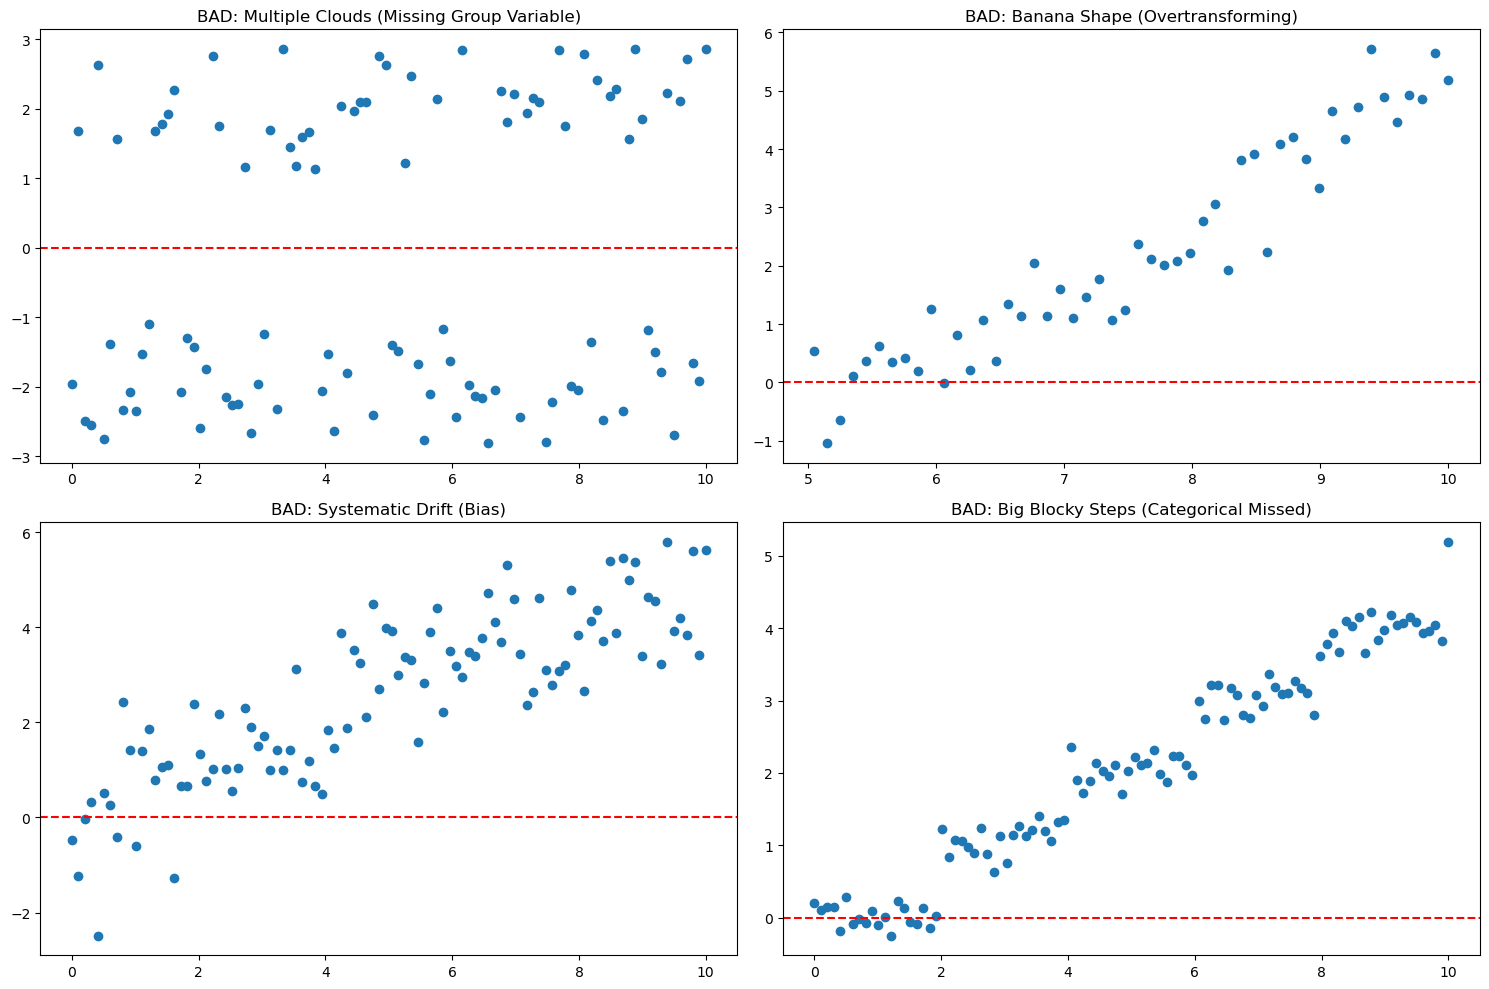

In [15]:
#Multiple clouds (forgot important group variable)
residuals_clouds = np.random.choice([-2, 2], size=n) + np.random.normal(0, 0.5, n)

#Banana shape (over-transformed / log weirdness)
residuals_banana = (x - 5)**1.5 / 2 + np.random.normal(0, 0.5, n)

#Random drift (bias)
residuals_drift = 0.5 * x + np.random.normal(0, 1, n)

#Big blocky steps (missing categorical variable)
residuals_blocks = np.floor(x / 2) + np.random.normal(0, 0.2, n)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

axs[0].scatter(x, residuals_clouds)
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title('BAD: Multiple Clouds (Missing Group Variable)')

axs[1].scatter(x, residuals_banana)
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title('BAD: Banana Shape (Overtransforming)')

axs[2].scatter(x, residuals_drift)
axs[2].axhline(0, color='r', linestyle='--')
axs[2].set_title('BAD: Systematic Drift (Bias)')

axs[3].scatter(x, residuals_blocks)
axs[3].axhline(0, color='r', linestyle='--')
axs[3].set_title('BAD: Big Blocky Steps (Categorical Missed)')

plt.tight_layout()
plt.show()

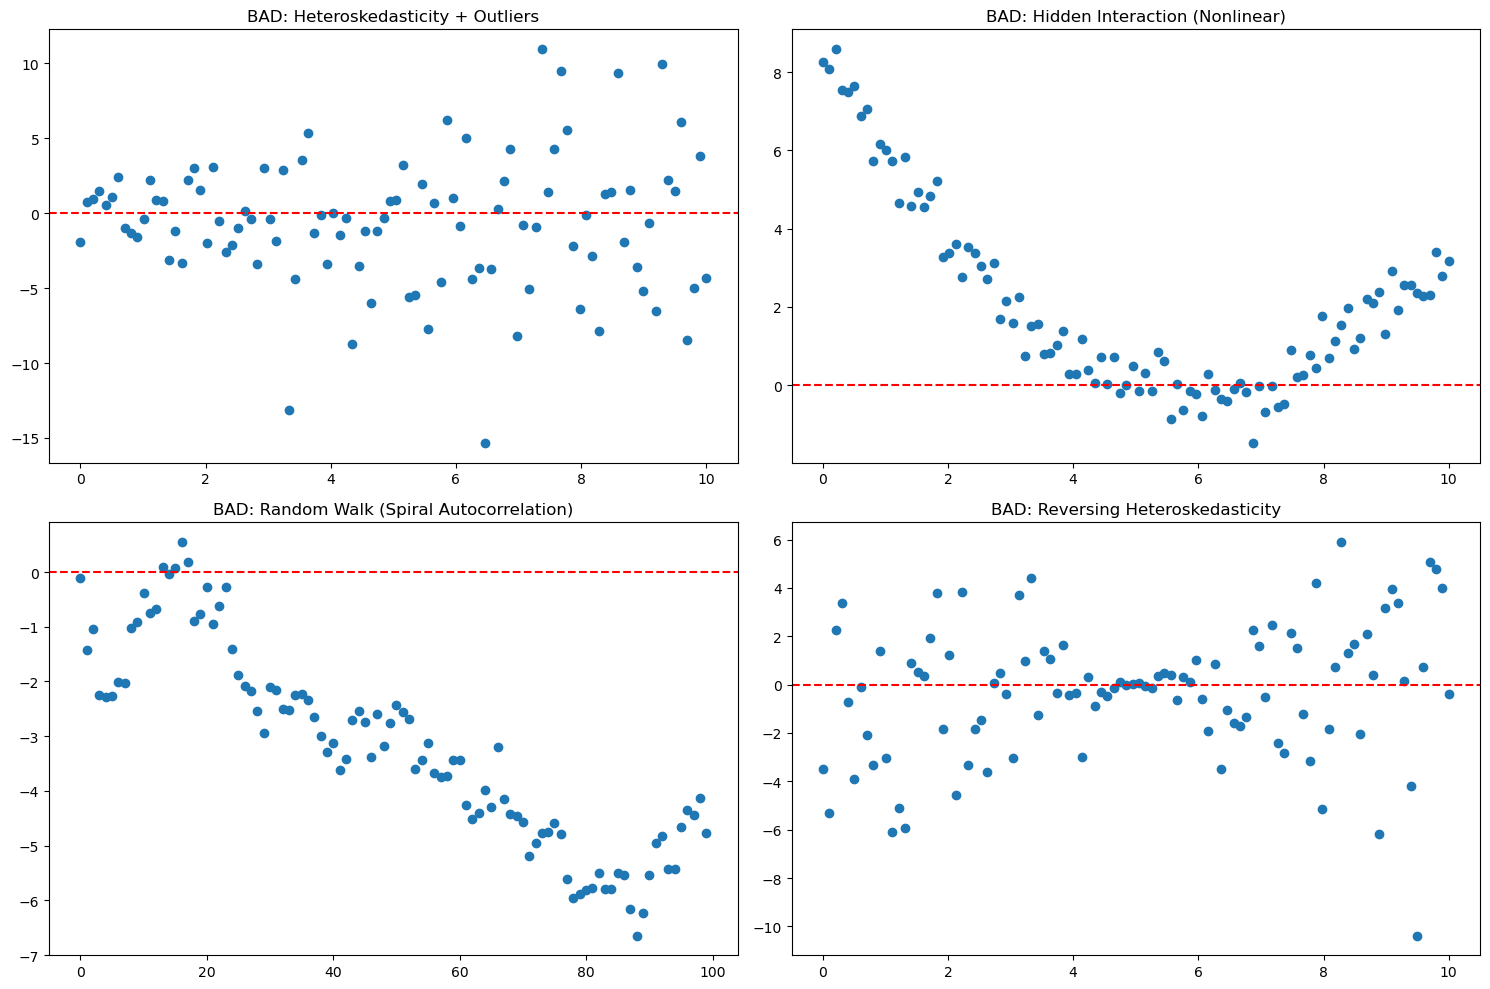

In [13]:
#Heteroskedasticity + Outliers together
residuals_hetero_outliers = np.random.normal(0, 0.5 * x + 1, n)
outlier_indices = np.random.choice(np.arange(n), size=5, replace=False)
residuals_hetero_outliers[outlier_indices] += np.random.choice([10, -10], size=5)

#Nonlinear interaction (hidden quadratic relationship)
residuals_hidden_interaction = (x - 5)*(x - 7)/4 + np.random.normal(0, 0.5, n)

#Time Series Autocorrelation Spiral
time = np.arange(n)
residuals_spiral = np.cumsum(np.random.normal(0, 0.5, n))  # random walk

#Heteroskedasticity that reverses (weird real-world case)
residuals_reversing_hetero = (np.abs(x - 5)) * np.random.normal(0, 1, n)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()

axs[0].scatter(x, residuals_hetero_outliers)
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title('BAD: Heteroskedasticity + Outliers')

axs[1].scatter(x, residuals_hidden_interaction)
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title('BAD: Hidden Interaction (Nonlinear)')

axs[2].scatter(time, residuals_spiral)
axs[2].axhline(0, color='r', linestyle='--')
axs[2].set_title('BAD: Random Walk (Spiral Autocorrelation)')

axs[3].scatter(x, residuals_reversing_hetero)
axs[3].axhline(0, color='r', linestyle='--')
axs[3].set_title('BAD: Reversing Heteroskedasticity')

plt.tight_layout()
plt.show()